# 스트리밍 모드

LangGraph에서는 그래프 실행 중에 발생하는 상태 변화와 LLM 출력을 실시간으로 확인할 수 있는 다양한 스트리밍 모드를 제공합니다. 이를 통해 복잡한 워크플로우의 진행 상황을 모니터링하고, 토큰 단위의 응답 스트리밍을 구현할 수 있습니다. 스트리밍은 사용자 경험을 크게 향상시키는 핵심 기능으로, 대규모 언어 모델의 응답을 기다리는 동안에도 중간 결과를 실시간으로 확인할 수 있게 해줍니다.

LangGraph는 여러 스트리밍(Streaming) 모드를 지원합니다. 각 모드는 서로 다른 수준의 정보를 제공하므로, 용도에 맞게 적절한 모드를 선택하여 사용할 수 있습니다.

주요 모드는 다음과 같습니다.

- `values`: 이 스트리밍 모드는 그래프의 값들을 스트리밍합니다. 이는 각 노드가 호출된 후의 **그래프의 전체 상태**를 의미합니다.
- `updates`: 이 스트리밍 모드는 그래프의 업데이트 내용을 스트리밍합니다. 이는 각 노드가 호출된 후의 **그래프 상태에 대한 업데이트**를 의미합니다.
- `messages`: 이 스트리밍 모드는 각 노드의 메시지를 스트리밍합니다. 이때 **LLM 의 토큰 단위의 출력 스트리밍** 도 가능합니다.

이 외에도 `astream_events()`를 사용하면 그래프 실행 중 발생하는 모든 이벤트를 세밀하게 추적할 수 있으며, 서브그래프 내부의 스트리밍까지 제어할 수 있습니다.

## 환경 설정

스트리밍 모드 예제를 위한 환경을 설정합니다. 환경 변수를 로드하고 LangSmith 추적을 활성화하여 각 스트리밍 모드의 실행 과정을 모니터링할 수 있도록 합니다.

아래 코드에서는 환경 변수 로드와 LangSmith 추적 설정을 수행합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangGraph-V1-Tutorial")

LangChain/LangSmith API Key가 설정되지 않았습니다. 참고: https://wikidocs.net/250954


## 에이전트 그래프 정의

스트리밍 모드를 테스트하기 위한 간단한 에이전트 그래프를 정의합니다. 이 에이전트는 Google 뉴스 검색 도구를 사용하여 사용자 질문에 응답하는 구조로 되어 있습니다. State, 도구, 노드, 엣지를 정의하고 그래프를 컴파일하여 이후 다양한 스트리밍 모드를 실험해 볼 수 있는 기반을 마련합니다.

> 참고 문서: [LangGraph Streaming](https://langchain-ai.github.io/langgraph/how-tos/streaming/)

아래 코드에서는 에이전트 그래프를 정의합니다.

In [2]:
from typing import Annotated, List, Dict
from typing_extensions import TypedDict
from langchain.tools import tool
from langchain_teddynote.tools import GoogleNews
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
# 키워드로 뉴스 검색하는 도구 생성
@tool
def search_keyword(query: str) -> List[Dict[str, str]]:
    """Look up news by keyword"""
    news_tool = GoogleNews()
    return "\n".join(
        [f'- {news["content"]}' for news in news_tool.search_by_keyword(query, k=5)]
    )


# 도구 리스트 생성
tools = [search_keyword]

# LLM 초기화 (OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능)
llm = init_chat_model("claude-sonnet-4-5")

# 도구와 LLM 결합
llm_with_tools = llm.bind_tools(tools)


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)

# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=[search_keyword])

# 도구 노드 추가
graph_builder.add_node("tools", tool_node)

# 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

########## 4. 엣지 추가 ##########

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

# 그래프 컴파일
graph = graph_builder.compile()

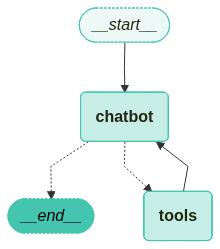

In [3]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

## 노드의 단계별 출력

LangGraph의 스트리밍은 LLM 출력 시 토큰 단위로 스트리밍하는 개념이 아니라, 그래프의 각 노드가 실행될 때마다 단계별로 결과를 출력하는 것을 의미합니다. 이를 통해 그래프 실행의 중간 과정을 실시간으로 확인할 수 있습니다.

주요 스트리밍 모드는 다음과 같습니다.

- `values`: 각 단계의 현재 상태 값 출력
- `updates`: 각 단계의 상태 업데이트만 출력 (기본값)
- `messages`: 각 단계의 메시지 출력 (토큰 단위 스트리밍 포함)

### stream_mode = "values"

`values` 모드는 각 단계의 현재 상태 값을 출력합니다. 그래프의 각 노드가 실행될 때마다 전체 State 가 반환되므로, 상태의 누적된 변화를 추적하기에 적합합니다. 이 모드는 디버깅이나 그래프 실행 과정을 상세히 모니터링할 때 유용합니다.

`chunk.items()` 에서 반환되는 값은 다음과 같습니다.

- `key`: State 의 key 값
- `value`: State 의 key 에 해당하는 value

### 동기(Synchronous) 방식의 스트리밍 - values

동기 방식에서는 `graph.stream()` 메서드를 사용합니다. `chunk` 는 dictionary 형태로, key 는 State 의 key, value 는 State 의 value 를 나타냅니다. `for` 루프를 사용하여 각 청크를 순차적으로 처리합니다.

아래 코드에서는 동기 방식으로 `values` 모드 스트리밍을 수행합니다.

In [4]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 동기 스트림 처리(stream_mode="values")
for chunk in graph.stream(inputs, stream_mode="values"):

    # chunk 는 dictionary 형태(key: State 의 key, value: State 의 value)
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

================================ Human Message =================================

AI 관련된 최신 뉴스를 검색해줘


================================== Ai Message ==================================

[{'id': 'toolu_01EGxqfJbfg88787JMzTrgQ8', 'input': {'query': 'AI'}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  search_keyword (toolu_01EGxqfJbfg88787JMzTrgQ8)
 Call ID: toolu_01EGxqfJbfg88787JMzTrgQ8
  Args:
    query: AI


================================= Tool Message =================================
Name: search_keyword

- 피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다 - 지디넷코리아
- 현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다 - 뉴시스
- [단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다 - 조선일보
- 한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아 - 조선일보
- 네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까 - v.daum.net


================================== Ai Message ==================================

AI 관련 최신 뉴스를 찾아드렸습니다:

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** - 지디넷코리아
   
2. **현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다** - 뉴시스

3. **[단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다** - 조선일보

4. **한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아** - 조선일보

5. **네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까** - v.daum.net

현재 주요 AI 뉴스는 현대차그룹의 대규모 AI 로봇 투자, 한국의 AI 오픈소스 활용 현황, 그리고 국내 IT 기업들의 AI 사업 전환 등이 주목받고 있네요.


### 비동기(Asynchronous) 방식의 스트리밍 - values

`astream()` 메서드는 비동기 스트림 처리를 통해 그래프를 실행하고 값 모드로 청크 단위 응답을 생성합니다. `async for` 문을 사용하여 비동기 스트림 처리를 수행하며, I/O 바운드 작업에서 더 나은 성능을 제공합니다. 비동기 방식은 여러 요청을 동시에 처리해야 하는 서버 환경에서 특히 유용합니다.

아래 코드에서는 비동기 방식으로 `values` 모드 스트리밍을 수행합니다.

In [5]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 비동기 스트림 처리(stream_mode="values")
async for chunk in graph.astream(inputs, stream_mode="values"):
    # chunk 는 dictionary 형태(key: State 의 key, value: State 의 value)
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

================================ Human Message =================================

AI 관련된 최신 뉴스를 검색해줘


================================== Ai Message ==================================

[{'id': 'toolu_01HvvmP5iQAg34joia3LQudF', 'input': {'query': 'AI'}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  search_keyword (toolu_01HvvmP5iQAg34joia3LQudF)
 Call ID: toolu_01HvvmP5iQAg34joia3LQudF
  Args:
    query: AI


================================= Tool Message =================================
Name: search_keyword

- 피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다 - 지디넷코리아
- 현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다 - 뉴시스
- [단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다 - 조선일보
- 한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아 - 조선일보
- 네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까 - v.daum.net


================================== Ai Message ==================================

AI 관련 최신 뉴스를 검색한 결과입니다:

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** - 지디넷코리아
   - 현대차그룹이 피지컬 AI 로봇에 대규모 투자를 발표했습니다.

2. **현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다** - 뉴시스
   - 현대차그룹이 로봇 기술의 피지컬 AI 전환을 가속화하고 있습니다.

3. **[단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다** - 조선일보
   - 새만금 지역에 AI, 수소, 로봇을 중심으로 한 대규모 투자 계획이 공개되었습니다.

4. **한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아** - 조선일보
   - 한국이 AI 개발 시 오픈소스를 활용하는 비율이 전 세계에서 가장 높은 것으로 나타났습니다.

5. **네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까** - Daum
   - 네이버와 카카오가 AI 기업으로 전환을 시도하며 수익 모델 강화를 추진하고 있습니다.

현재 한국에서는 현대차그룹의 대규모 AI·로봇 투자와 주요 IT 기업들의 AI 중심 전환이 주요 화두인 것으로 보입니다.


스트리밍 과정에서 중간 결과 없이 최종 결과만 확인하고 싶은 경우에는, 스트림의 마지막 청크만 저장하여 사용할 수 있습니다. 이 패턴은 스트리밍의 이점을 유지하면서도 최종 출력만 필요한 상황에서 활용됩니다.

아래 코드에서는 최종 결과만 추출하는 방법을 보여줍니다.

In [6]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

final_result = None

# 비동기 스트림 처리(stream_mode="values")
async for chunk in graph.astream(inputs, stream_mode="values"):
    final_result = chunk

# 최종 결과 출력
print(final_result["messages"][-1].content)

AI 관련 최신 뉴스를 검색한 결과입니다:

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** - 지디넷코리아
   
2. **현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다** - 뉴시스

3. **[단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다** - 조선일보

4. **한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아** - 조선일보

5. **네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까** - v.daum.net

주요 트렌드를 보면 현대차그룹의 대규모 AI 및 로봇 투자, 한국의 높은 AI 오픈소스 활용률, 그리고 국내 IT 대기업들의 AI 전환이 주목받고 있네요. 더 자세한 정보가 필요하시면 말씀해주세요!


### stream_mode = "updates"

`updates` 모드는 각 단계에 대한 업데이트된 State 만 내보냅니다. `values` 모드와 달리 전체 상태가 아닌 해당 노드에서 변경된 부분만 반환하므로, 데이터 전송량이 적고 각 노드의 기여분을 명확하게 파악할 수 있습니다.

출력은 노드 이름을 key 로, 업데이트된 값을 value 로 하는 `dictionary` 입니다. `chunk.items()` 에서 반환되는 값은 다음과 같습니다.

- `key`: 노드(Node) 의 이름
- `value`: 해당 노드(Node) 단계에서의 출력 값(dictionary). 즉, 여러 개의 key-value 쌍을 가진 dictionary 입니다.

### 동기(Synchronous) 방식의 스트리밍 - updates

동기 방식에서는 `graph.stream()` 메서드를 사용합니다. 각 청크에서 노드 이름과 해당 노드의 업데이트된 상태를 확인할 수 있습니다. `updates` 모드에서는 어떤 노드가 어떤 출력을 생성했는지 명확하게 구분됩니다.

아래 코드에서는 동기 방식으로 `updates` 모드 스트리밍을 수행합니다.

In [7]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 동기 스트림 처리(stream_mode="updates")
for chunk in graph.stream(inputs, stream_mode="updates"):
    # chunk 는 dictionary 형태(key: 노드, value: 노드의 상태 값)
    for node, value in chunk.items():
        if node:
            print(f"\n[Node: {node}]\n")
        if "messages" in value:
            value["messages"][-1].pretty_print()


[Node: chatbot]

================================== Ai Message ==================================

[{'id': 'toolu_0164tq7wP5X6nUtLVA9jtRK3', 'input': {'query': 'AI'}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  search_keyword (toolu_0164tq7wP5X6nUtLVA9jtRK3)
 Call ID: toolu_0164tq7wP5X6nUtLVA9jtRK3
  Args:
    query: AI



[Node: tools]

================================= Tool Message =================================
Name: search_keyword

- 피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다 - 지디넷코리아
- 현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다 - 뉴시스
- [단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다 - 조선일보
- 한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아 - 조선일보
- 네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까 - v.daum.net



[Node: chatbot]

================================== Ai Message ==================================

AI 관련 최신 뉴스를 검색한 결과입니다:

## 주요 AI 뉴스

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** - 지디넷코리아

2. **현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다** - 뉴시스

3. **[단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다** - 조선일보

4. **한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아** - 조선일보

5. **네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까** - v.daum.net

현재 가장 주목받는 뉴스는 현대차그룹의 대규모 AI 및 로봇 투자와 관련된 소식이며, 한국 기업들의 AI 기술 개발 및 사업 전환에 관한 내용들이 주를 이루고 있습니다.


### 비동기(Asynchronous) 방식의 스트리밍 - updates

비동기 방식에서는 `graph.astream()` 메서드와 `async for` 문을 사용합니다. 이 방식은 I/O 바운드 작업에서 성능 향상을 제공하며, 특히 외부 API 호출이 포함된 그래프에서 효율적입니다.

아래 코드에서는 비동기 방식으로 `updates` 모드 스트리밍을 수행합니다.

In [8]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 비동기 스트림 처리(stream_mode="updates")
async for chunk in graph.astream(inputs, stream_mode="updates"):
    # chunk 는 dictionary 형태(key: 노드, value: 노드의 상태 값)
    for node, value in chunk.items():
        if node:
            print(f"\n[Node: {node}]\n")
        if "messages" in value:
            value["messages"][-1].pretty_print()


[Node: chatbot]

================================== Ai Message ==================================

[{'id': 'toolu_01EGYGQnsDiFmzv6TyxE5Aap', 'input': {'query': 'AI'}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  search_keyword (toolu_01EGYGQnsDiFmzv6TyxE5Aap)
 Call ID: toolu_01EGYGQnsDiFmzv6TyxE5Aap
  Args:
    query: AI



[Node: tools]

================================= Tool Message =================================
Name: search_keyword

- 피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다 - 지디넷코리아
- 현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다 - 뉴시스
- [단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다 - 조선일보
- 한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아 - 조선일보
- 네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까 - v.daum.net



[Node: chatbot]

================================== Ai Message ==================================

AI 관련 최신 뉴스를 검색했습니다. 주요 내용은 다음과 같습니다:

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** (지디넷코리아)
   - 현대차그룹이 로봇 기술에 대규모 투자를 진행

2. **현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다** (뉴시스)
   - 피지컬 AI(Physical AI) 기술 전환에 집중

3. **현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다** (조선일보)
   - AI, 수소, 로봇을 3대 미래 사업으로 육성

4. **한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아** (조선일보)
   - 한국의 AI 개발에서 오픈소스 활용률이 세계 최고 수준

5. **네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까** (다음)
   - 국내 주요 IT기업들의 AI 기업 전환 노력

현재 국내 AI 뉴스는 현대차그룹의 대규모 투자와 네이버·카카오 등 IT기업들의 AI 전환이 주요 이슈네요!


### stream_mode = "messages"

`messages` 모드는 각 단계에 대한 메시지를 스트리밍합니다. 이 모드의 가장 큰 특징은 LLM 의 토큰 단위 실시간 스트리밍이 가능하다는 점입니다. 사용자에게 응답이 생성되는 과정을 실시간으로 보여줄 수 있어, 대화형 애플리케이션에서 특히 유용합니다.

`chunk` 는 두 개의 요소를 가진 tuple 입니다.

- `chunk_msg`: 실시간 출력 메시지
- `metadata`: 노드 정보 (어떤 노드에서 발생한 메시지인지 확인 가능)

### 동기(Synchronous) 방식의 스트리밍 - messages

`messages` 모드의 동기 방식에서는 LLM의 토큰 단위 출력을 실시간으로 받을 수 있습니다. `metadata["langgraph_node"]`를 통해 특정 노드에서 발생한 메시지만 필터링할 수 있으며, 이를 통해 도구 호출 메시지와 최종 응답 메시지를 구분하여 처리할 수 있습니다.

아래 코드에서는 chatbot 노드의 메시지만 출력합니다.

In [9]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 동기 스트림 처리(stream_mode="messages")
# chunk_msg: 실시간 출력 메시지, metadata: 노드 정보
for chunk_msg, metadata in graph.stream(inputs, stream_mode="messages"):

    # chatbot 노드에서 출력된 메시지만 출력
    if metadata["langgraph_node"] == "chatbot":
        if chunk_msg.content:
            print(chunk_msg.content, end="", flush=True)

    else:
        print(chunk_msg.content)
        print(f"\n\nmetadata: \n{metadata}\n\n")

[{'id': 'toolu_01ReCE5aKDMLDAb3hta64dH1', 'input': {}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}, 'index': 0}]

[{'partial_json': '', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': '{"qu', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': 'ery"', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': ': "AI"}', 'type': 'input_json_delta', 'index': 0}]

...

[{'text': '박차를 가하고 ', 'type': 'text', 'index': 0}]

[{'text': '있다', 'type': 'text', 'index': 0}]

[{'text': '는 소', 'type': 'text', 'index': 0}]

[{'text': '식이 ', 'type': 'text', 'index': 0}]

[{'text': '눈에 띕니다.', 'type': 'text', 'index': 0}]

### 비동기(Asynchronous) 방식의 스트리밍 - messages

`messages` 모드의 비동기 방식도 동일하게 토큰 단위 스트리밍을 지원합니다. 비동기 방식은 `astream()` 메서드와 `async for` 문을 사용하여 구현합니다.

아래 코드에서는 비동기 방식으로 메시지를 스트리밍합니다.

In [10]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 비동기 스트림 처리(stream_mode="messages")
# chunk_msg: 실시간 출력 메시지, metadata: 노드 정보
async for chunk_msg, metadata in graph.astream(inputs, stream_mode="messages"):
    # chatbot 노드에서 출력된 메시지만 출력
    if metadata["langgraph_node"] == "chatbot":
        if chunk_msg.content:
            print(chunk_msg.content, end="", flush=True)
    else:
        print(chunk_msg.content)

[{'id': 'toolu_01Tdj51moVfxUUPSsHf3e5fG', 'input': {}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}, 'index': 0}]

[{'partial_json': '', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': '{"quer', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': 'y": "AI"}', 'type': 'input_json_delta', 'index': 0}]

- 피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다 - 지디넷코리아
- 현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다 - 뉴시스
- [단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다 - 조선일보
- 한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아 - 조선일보
- 네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까 - v.daum.net


...

[{'text': ' 초', 'type': 'text', 'index': 0}]

[{'text': '점이', 'type': 'text', 'index': 0}]

[{'text': ' 맞춰져 있', 'type': 'text', 'index': 0}]

[{'text': '네', 'type': 'text', 'index': 0}]

[{'text': '요.', 'type': 'text', 'index': 0}]

## 특정 노드에 대한 출력 스트리밍

실제 애플리케이션에서는 모든 노드의 출력이 아닌, 특정 노드에서 발생한 메시지만 선택적으로 출력해야 하는 경우가 많습니다. `metadata["langgraph_node"]` 를 통해 현재 메시지가 어떤 노드에서 생성되었는지 확인할 수 있으며, 이를 활용하여 원하는 노드의 출력만 필터링할 수 있습니다.

아래에서는 `with_config(tags=[...])` 를 사용하여 LLM 에 태그를 추가한 후, 특정 노드의 메시지만 선별적으로 출력하는 방법을 살펴보겠습니다.

In [11]:
from typing import Annotated, List, Dict
from typing_extensions import TypedDict
from langchain.tools import tool
from langchain_teddynote.tools import GoogleNews
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
# 키워드로 뉴스 검색하는 도구 생성
@tool
def search_keyword(query: str) -> List[Dict[str, str]]:
    """Look up news by keyword"""
    news_tool = GoogleNews()
    return "\n".join(
        [f'- {news["content"]}' for news in news_tool.search_by_keyword(query, k=5)]
    )


# 도구 리스트 생성
tools = [search_keyword]

# LLM 초기화 (OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능)
llm = init_chat_model("claude-sonnet-4-5")

# 도구와 LLM 결합 (tags 추가)
llm_with_tools = llm.bind_tools(tools).with_config(tags=["WANT_TO_STREAM"])


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)

# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=[search_keyword])

# 도구 노드 추가
graph_builder.add_node("tools", tool_node)

# 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

########## 4. 엣지 추가 ##########

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

# 그래프 컴파일
graph = graph_builder.compile()

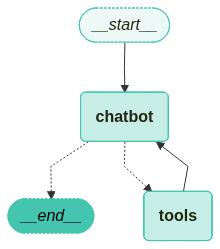

In [12]:
visualize_graph(graph, xray=True)

특정 노드(Node)에 대해서만 출력하고 싶은 경우, `stream_mode="messages"` 를 사용하여 설정할 수 있습니다. 이 모드에서는 (`chunk_msg`, `metadata`) 형태의 tuple 로 메시지를 받게 됩니다.

- `chunk_msg` 는 실시간 출력 메시지를 나타냅니다.
- `metadata` 는 노드 정보를 포함하고 있습니다.

`metadata["langgraph_node"]` 를 통해 특정 노드에서 출력된 메시지만 선택적으로 출력할 수 있습니다. 예를 들어 chatbot 노드에서 출력된 메시지만 출력하려면 `metadata["langgraph_node"] == "chatbot"` 조건을 사용합니다.

아래 코드에서는 chatbot 노드의 메시지만 필터링하여 출력합니다.

In [13]:
from langchain_core.messages import HumanMessage

# 사용자의 메시지를 딕셔너리 형태로 입력 데이터 구성
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# stream_mode="messages" 를 통한 스트리밍 처리
for chunk_msg, metadata in graph.stream(inputs, stream_mode="messages"):
    # HumanMessage 가 아닌 최종 노드의 유효한 컨텐츠만 출력 처리
    if (
        chunk_msg.content
        and not isinstance(chunk_msg, HumanMessage)
        and metadata["langgraph_node"] == "chatbot"
    ):
        print(chunk_msg.content, end="", flush=True)

[{'id': 'toolu_018j3Gy8TgYDTAVihr68KvyU', 'input': {}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}, 'index': 0}]

[{'partial_json': '', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': '{"query": "', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': 'AI', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': '"}', 'type': 'input_json_delta', 'index': 0}]

...

[{'text': ' 기업 전', 'type': 'text', 'index': 0}]

[{'text': '환 등', 'type': 'text', 'index': 0}]

[{'text': '으', 'type': 'text', 'index': 0}]

[{'text': '로 보', 'type': 'text', 'index': 0}]

[{'text': '입니다.', 'type': 'text', 'index': 0}]

`metadata` 를 출력하면 노드 정보를 확인할 수 있습니다. `metadata` 딕셔너리에는 `langgraph_node`, `langgraph_triggers`, `langgraph_step` 등 그래프 실행에 관한 다양한 메타 정보가 포함되어 있습니다.

In [14]:
metadata

{'langgraph_step': 3,
 'langgraph_node': 'chatbot',
 'langgraph_triggers': ('branch:to:chatbot',),
 'langgraph_path': ('__pregel_pull', 'chatbot'),
 'langgraph_checkpoint_ns': 'chatbot:e839d028-ab28-ae65-56ef-259377b1c1f6',
 'checkpoint_ns': 'chatbot:e839d028-ab28-ae65-56ef-259377b1c1f6',
 'ls_provider': 'anthropic',
 'ls_model_name': 'claude-sonnet-4-5',
 'ls_model_type': 'chat',
 'ls_temperature': None,
 'ls_max_tokens': 64000,
 'tags': ['WANT_TO_STREAM']}

## 사용자 정의 tag 필터링 스트리밍

LLM 의 출력이 여러 군데에서 발생하는 경우, 특정 노드에서 출력된 메시지만 출력하고 싶을 수 있습니다. 이러한 경우 `tags` 를 추가하여 출력하고 싶은 노드만 선별할 수 있습니다. 태그 기반 필터링은 복잡한 그래프에서 여러 LLM 호출이 있을 때 특히 유용합니다.

LLM 에 tags 를 추가하는 방법은 다음과 같습니다. `tags` 는 리스트 형태로 추가할 수 있습니다.

```python
llm.with_config(tags=["WANT_TO_STREAM"])
```

이를 통해 `astream_events()` 에서 이벤트를 더 정확하게 필터링하여, 해당 모델에서 발생한 이벤트만 유지할 수 있습니다.

아래 예시는 `astream_events()` 를 사용하여 `WANT_TO_STREAM` 태그가 있는 이벤트만 필터링하여 출력하는 예시입니다. `on_chat_model_stream` 이벤트 중 특정 태그를 포함하는 것만 선택하여 토큰 단위 스트리밍을 수행합니다.

아래 코드에서는 태그 기반 필터링 스트리밍을 구현합니다.

In [15]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 비동기 이벤트 스트림 처리(astream_events)
async for event in graph.astream_events(inputs, version="v2"):
    # 이벤트 종류와 태그 정보 추출
    kind = event["event"]
    tags = event.get("tags", [])

    # 채팅 모델 스트림 이벤트 및 최종 노드 태그 필터링
    if kind == "on_chat_model_stream" and "WANT_TO_STREAM" in tags:
        # 이벤트 데이터 추출
        data = event["data"]

        # 출력 메시지
        if data["chunk"].content:
            print(data["chunk"].content, end="", flush=True)

[{'id': 'toolu_013thL8EyxgHqCdk7xzNyZHd', 'input': {}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}, 'index': 0}]

[{'partial_json': '', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': '{"qu', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': 'ery": "A', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': 'I"}', 'type': 'input_json_delta', 'index': 0}]

...

[{'text': ' 기업들', 'type': 'text', 'index': 0}]

[{'text': '의 AI 전환 움', 'type': 'text', 'index': 0}]

[{'text': '직임이', 'type': 'text', 'index': 0}]

[{'text': '네', 'type': 'text', 'index': 0}]

[{'text': '요.', 'type': 'text', 'index': 0}]

## 도구 호출에 대한 스트리밍 출력

도구 호출이 포함된 에이전트에서는 도구 호출 과정도 스트리밍으로 확인할 수 있습니다. `AIMessageChunk` 는 실시간 토큰 단위의 출력 메시지를 나타내며, `tool_call_chunks` 속성을 통해 도구 호출 정보가 포함된 청크를 식별할 수 있습니다.

만약 `tool_call_chunks` 가 존재하는 경우, 도구 호출 청크를 누적하여 완전한 도구 호출 정보를 구성할 수 있습니다. 이 패턴은 도구 호출의 진행 상황을 실시간으로 모니터링하는 데 유용합니다.

아래 코드에서는 도구 호출 스트리밍을 구현합니다.

In [16]:
from langchain_core.messages import AIMessageChunk, HumanMessage

# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 첫 번째 메시지 처리 여부 플래그 설정
first = True

# 동기 스트림 처리를 통한 메시지 및 메타데이터 순차 처리
for msg, metadata in graph.stream(inputs, stream_mode="messages"):
    # 사용자 메시지가 아닌 경우의 컨텐츠 출력 처리
    if msg.content and not isinstance(msg, HumanMessage):
        print(msg.content, end="", flush=True)

    # AI 메시지 청크 처리 및 누적
    if isinstance(msg, AIMessageChunk):
        if first:
            gathered = msg
            first = False
        else:
            gathered = gathered + msg

        # 도구 호출 청크 존재 시 누적된 도구 호출 정보 출력
        if msg.tool_call_chunks:
            print(gathered.tool_calls[0]["args"])

[{'id': 'toolu_01LvyxScvuWDcZNsuyWBDqjG', 'input': {}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}, 'index': 0}]

{}
[{'partial_json': '', 'type': 'input_json_delta', 'index': 0}]

{}
[{'partial_json': '{"query":', 'type': 'input_json_delta', 'index': 0}]

{}
[{'partial_json': ' "AI', 'type': 'input_json_delta', 'index': 0}]

{'query': 'AI'}
[{'partial_json': '"}', 'type': 'input_json_delta', 'index': 0}]

...

[{'text': '요 이', 'type': 'text', 'index': 0}]

[{'text': '슈로 다뤄', 'type': 'text', 'index': 0}]

[{'text': '지', 'type': 'text', 'index': 0}]

[{'text': '고 있네', 'type': 'text', 'index': 0}]

[{'text': '요.', 'type': 'text', 'index': 0}]

## Subgraphs 스트리밍 출력

이번에는 Subgraphs 를 통해 스트리밍 출력을 확인하는 방법을 알아보겠습니다. Subgraphs 는 그래프의 일부를 독립적인 서브그래프로 정의하는 기능으로, 복잡한 워크플로우를 모듈화하여 관리할 수 있게 해줍니다.

이 예제에서의 흐름은 다음과 같습니다.

- Subgraphs 에서는 기존의 최신 뉴스를 검색하는 기능을 재사용합니다.
- Parent Graph 에서는 검색된 최신 뉴스를 바탕으로 SNS 포스트를 생성하는 기능을 추가합니다.

아래 코드에서는 서브그래프가 포함된 메인 그래프를 정의합니다.

In [17]:
from typing import Annotated, List, Dict
from typing_extensions import TypedDict
from langchain.tools import tool
from langchain_teddynote.tools import GoogleNews
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
# 키워드로 뉴스 검색하는 도구 생성
@tool
def search_keyword(query: str) -> List[Dict[str, str]]:
    """Look up news by keyword"""
    news_tool = GoogleNews()
    return "\n".join(
        [f'- {news["content"]}' for news in news_tool.search_by_keyword(query, k=5)]
    )


# 도구 리스트 생성
tools = [search_keyword]

# LLM 초기화 (OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능)
llm = init_chat_model("claude-sonnet-4-5")

# 도구와 LLM 결합 (tags 추가)
llm_with_tools = llm.bind_tools(tools).with_config(tags=["WANT_TO_STREAM"])


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# SNS 포스트 생성 함수 정의
def create_sns_post(state: State):
    # SNS 포스트 생성을 위한 프롬프트
    sns_prompt = """
    이전 대화 내용을 바탕으로 SNS 게시글 형식으로 변환해주세요.
    다음 형식을 따라주세요:
    - 해시태그 포함
    - 이모지 사용
    - 간결하고 흥미로운 문체 사용
    - 200자 이내로 작성
    """
    messages = state["messages"] + [("human", sns_prompt)]
    # SNS 포스트용 LLM (OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능)
    sns_llm = init_chat_model("claude-sonnet-4-5").with_config(tags=["WANT_TO_STREAM2"])
    return {"messages": [sns_llm.invoke(messages)]}


# 서브그래프 생성 함수
def create_subgraph():
    # 서브그래프용 상태 그래프 생성
    subgraph = StateGraph(State)

    # 챗봇 노드 추가
    subgraph.add_node("chatbot", chatbot)

    # 도구 노드 생성 및 추가
    tool_node = ToolNode(tools=[search_keyword])
    subgraph.add_node("tools", tool_node)

    # 조건부 엣지 추가
    subgraph.add_conditional_edges(
        "chatbot",
        tools_condition,
    )

    # tools > chatbot
    subgraph.add_edge("tools", "chatbot")

    # START > chatbot
    subgraph.add_edge(START, "chatbot")

    # chatbot > END
    subgraph.add_edge("chatbot", END)

    return subgraph.compile()


# 메인 그래프 생성
graph_builder = StateGraph(State)

# 서브그래프 추가
subgraph = create_subgraph()
graph_builder.add_node("news_subgraph", subgraph)

# SNS 포스트 생성 노드 추가
graph_builder.add_node("sns_post", create_sns_post)

# START > news_subgraph
graph_builder.add_edge(START, "news_subgraph")

# news_subgraph > sns_post
graph_builder.add_edge("news_subgraph", "sns_post")

# sns_post > END
graph_builder.add_edge("sns_post", END)

# 그래프 컴파일
graph = graph_builder.compile()

### 그래프 시각화

서브그래프가 포함된 전체 그래프를 시각화합니다. `news_subgraph` 노드 내부에 뉴스 검색 에이전트가 포함되어 있고, `sns_post` 노드에서 SNS 포스트를 생성하는 구조입니다. `xray=True` 옵션을 사용하면 서브그래프 내부 구조까지 확인할 수 있습니다.

아래 코드는 그래프를 시각화합니다.

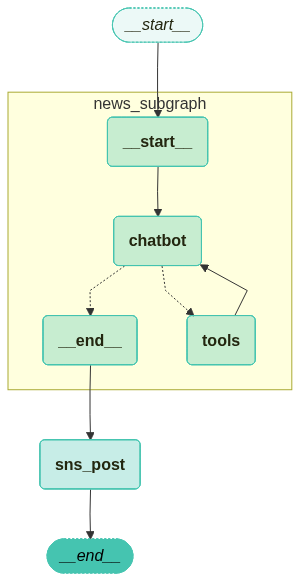

In [18]:
# 그래프 시각화
visualize_graph(graph, xray=True)

### Subgraphs 출력을 생략하는 경우

기본적으로 `stream()` 메서드는 서브그래프의 내부 업데이트를 생략하고, 서브그래프 전체의 최종 출력만 보여줍니다. 이는 상위 수준의 워크플로우 진행 상황만 확인하고 싶을 때 유용합니다. 서브그래프 내부에서 어떤 노드들이 실행되었는지는 보이지 않고, 서브그래프가 하나의 노드처럼 동작하여 최종 결과만 전달됩니다.

아래 코드에서는 서브그래프 내부를 생략한 스트리밍을 수행합니다.

In [19]:
# 질문 입력
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}

# 노드 업데이트 정보 순차적 처리 및 출력
for chunk in graph.stream(inputs, stream_mode="updates"):
    # node_name: 현재 처리 중인 노드명, node_chunk: 해당 노드의 청크 데이터
    for node_name, node_chunk in chunk.items():
        # 현재 처리 중인 노드 구분선 출력
        print(f"\n========= Update from node {node_name} =========\n")
        # 해당 노드의 업데이트된 데이터 출력
        if "messages" in node_chunk:
            node_chunk["messages"][-1].pretty_print()
        else:
            print(node_chunk)


========= Update from node news_subgraph =========

================================== Ai Message ==================================

AI 관련 최신 뉴스를 검색했습니다. 주요 뉴스는 다음과 같습니다:

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** - 지디넷코리아
   - 현대차그룹의 대규모 로봇 기술 투자 소식

2. **현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다** - 뉴시스
   - 피지컬 AI로의 전환에 속도를 내는 현대차그룹

3. **[단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다** - 조선일보
   - 새만금 지역에 AI, 수소, 로봇 분야 집중 투자 계획

4. **한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아** - 조선일보
   - 한국의 AI 개발 환경에서 오픈소스 활용도가 세계 최고 수준

5. **네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까** - v.daum.net
   - 네이버와 카카오의 AI 기업으로의 전환 및 수익성 강화 노력

현재 국내 AI 뉴스는 현대차그룹의 피지컬 AI 로봇 투자와 네이버·카카오 같은 IT 기업들의 AI 전환이 주요 이슈로 다뤄지고 있습니다.



========= Update from node sns_post =========

================================== Ai Message ==================================

🤖 AI 뉴스 속보! 

현대차그룹이 피지컬 AI 로봇에 무려 125조원 투자 결정! 🚀
새만금에는 AI·수소·로봇 미래 3대 축 구축 중 💪

네이버·카카오도 AI 기업으로 대변신 중 ✨
한국의 오픈소스 AI 개발 비율, 전세계 1위 달성! 🏆

AI 시대, 대한민국이 앞서간다! 🇰🇷

#AI #인공지능 #현대차그룹 #피지컬AI #로봇 #네이버 #카카오 #오픈소스 #새만금 #미래기술


### Subgraphs 출력도 포함하는 경우

`subgraphs=True` 옵션을 사용하면 서브그래프의 내부 업데이트도 함께 스트리밍할 수 있습니다. 이 경우 출력은 `(namespace, chunk)` 형태의 tuple 로 반환됩니다. `namespace` 를 통해 현재 업데이트가 메인 그래프에서 발생한 것인지, 서브그래프 내부에서 발생한 것인지 구분할 수 있습니다.

아래 코드에서는 서브그래프 내부 업데이트를 포함한 스트리밍을 수행합니다.

In [20]:
# 사용자의 메시지를 딕셔너리 형태로 입력 데이터 구성
inputs = {"messages": [("human", "AI 관련된 최신 뉴스를 검색해줘")]}


# 네임스페이스 문자열을 보기 좋은 형식으로 변환하는 포맷팅 함수
def format_namespace(namespace):
    return namespace[-1].split(":")[0] if len(namespace) > 0 else "parent graph"


# subgraphs=True 를 통해 서브그래프의 출력도 포함(namespace, chunk) 형태로 출력됩니다.
for namespace, chunk in graph.stream(inputs, stream_mode="updates", subgraphs=True):
    # node_name: 현재 처리 중인 노드명, node_chunk: 해당 노드의 청크 데이터
    for node_name, node_chunk in chunk.items():
        print(
            f"\n========= Update from node [{node_name}] in [{format_namespace(namespace)}] =========\n"
        )

        # 노드의 청크 데이터 출력
        if "messages" in node_chunk:
            node_chunk["messages"][-1].pretty_print()
        else:
            print(node_chunk)


========= Update from node [chatbot] in [news_subgraph] =========

================================== Ai Message ==================================

[{'id': 'toolu_0194HfUx5QxHsd3dEkgE7gDm', 'input': {'query': 'AI'}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  search_keyword (toolu_0194HfUx5QxHsd3dEkgE7gDm)
 Call ID: toolu_0194HfUx5QxHsd3dEkgE7gDm
  Args:
    query: AI



========= Update from node [tools] in [news_subgraph] =========

================================= Tool Message =================================
Name: search_keyword

- 피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다 - 지디넷코리아
- 현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다 - 뉴시스
- [단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다 - 조선일보
- 한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아 - 조선일보
- 네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까 - v.daum.net



========= Update from node [chatbot] in [news_subgraph] =========

================================== Ai Message ==================================

AI 관련 최신 뉴스를 검색했습니다. 주요 내용은 다음과 같습니다:

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** - 지디넷코리아
   - 현대차그룹이 대규모 투자로 피지컬 AI 로봇 개발을 가속화하고 있습니다.

2. **현대차그룹, 로봇 기술 고도화 지속…피지컬 AI 전환 속도 높인다** - 뉴시스
   - 현대차그룹의 피지컬 AI 전환 전략에 대한 소식입니다.

3. **[단독]현대차그룹, 새만금에 10조 투자해 AI, 수소, 로봇 미래 3대 축 키운다** - 조선일보
   - 현대차그룹이 새만금에 AI, 수소, 로봇을 중심으로 한 미래 사업에 대규모 투자를 계획하고 있습니다.

4. **한국, AI 개발 때 오픈소스 택하는 비율 세계에서 제일 높아** - 조선일보
   - 한국의 AI 개발 환경에서 오픈소스 활용도가 세계 최고 수준이라는 내용입니다.

5. **네이버·카카오, AI기업 탈바꿈…돈벌이 강화될까** - v.daum.net
   - 국내 주요 IT 기업들의 AI 기업으로의 전환과 수익성 개선 전망에 대한 뉴스입니다.

현대차그룹의 피지컬 AI 투자와 국내 IT 기업들의 AI 전환이 주요 화두인 것으로 보입니다.

========= Update from node [news_subgraph] in [parent graph] =========

================================== Ai Message ==================================

AI 관련 최신 뉴스를 검색했습니다. 주요 내용은 다음과 같습니다:

1. **피지컬 AI 로봇, 산업 현장으로…현대차그룹 125조원 투자한다** - 지디넷코리아
  


========= Update from node [sns_post] in [parent graph] =========

================================== Ai Message ==================================

🤖 AI 뉴스 속보! 🔥

현대차그룹이 125조원을 쏟아붓는다! 
피지컬 AI 로봇이 산업 현장으로 🏭

새만금에 10조 투자로 AI·수소·로봇 
미래 3대 축 본격화 💪

한국, AI 오픈소스 활용 세계 1위 🥇
네이버·카카오도 AI 기업으로 변신 중!

AI 시대, 한국이 달린다 🚀

#AI #인공지능 #현대차그룹 #피지컬AI 
#로봇 #새만금 #네이버 #카카오 
#오픈소스 #미래기술 #테크뉴스


### Subgraphs 안에서 LLM 출력 토큰 단위 스트리밍

`astream_events()` 메서드를 사용하면 서브그래프 내부에서 발생하는 LLM 출력을 토큰 단위로 스트리밍할 수 있습니다. 이벤트 종류(`on_chat_model_start`, `on_chat_model_stream`, `on_tool_start`, `on_tool_end`)에 따라 적절한 처리를 수행하여, 서브그래프 내부의 세밀한 실행 과정을 모니터링할 수 있습니다.

아래 코드에서는 서브그래프 내부의 토큰 스트리밍을 구현합니다.

`kind` 는 이벤트 종류를 나타내며, 주요 이벤트 종류에는 `on_chat_model_start`, `on_chat_model_stream`, `on_tool_start`, `on_tool_end` 등이 있습니다. 각 이벤트에 따라 적절한 출력 처리를 수행합니다.

- 이벤트 종류에 대한 상세 정보는 [StreamEvent 타입별 정리](https://wikidocs.net/265576) 에서 확인할 수 있습니다.

In [21]:
# 네임스페이스 정보를 파싱하는 함수
def parse_namespace_info(info: tuple) -> tuple[str, str]:
    if len(info) > 1:
        namespace, node_name = info
        return node_name.split(":")[0], namespace.split(":")[0]
    return info[0].split(":")[0], "parent graph"


kind = None

async for event in graph.astream_events(inputs, version="v2", subgraphs=True):
    kind = event["event"]

    # 이벤트 종류와 태그 정보 추출
    if kind == "on_chat_model_start":
        print(f"\n========= on_chat_model_start =========\n")

    # 채팅 모델 스트림 이벤트 및 최종 노드 태그 필터링
    elif kind == "on_chat_model_stream":
        # 이벤트 데이터 추출
        data = event["data"]

        # 토큰 단위의 스트리밍 출력
        if data["chunk"].content:
            print(data["chunk"].content, end="", flush=True)

    elif kind == "on_tool_start":
        print(f"\n========= tool_start =========\n")
        data = event["data"]
        if "input" in data:
            tool_msg = data["input"]
            print(tool_msg)

    elif kind == "on_tool_end":
        print(f"\n========= tool_end =========\n")
        data = event["data"]
        if "output" in data:
            tool_msg = data["output"]
            print(tool_msg.content)


========= on_chat_model_start =========



[{'id': 'toolu_018NQkPEZdrrRxQCk2XDLy39', 'input': {}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}, 'index': 0}]

[{'partial_json': '', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': '{"qu', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': 'ery": "', 'type': 'input_json_delta', 'index': 0}]

...

래기

술 #새

만금 #테

크

뉴스

### 특정 tags 만 스트리밍 출력하는 경우

`ONLY_STREAM_TAGS` 를 통해 스트리밍 출력하고 싶은 tags 만 설정할 수 있습니다. 이 방법을 사용하면 여러 LLM 호출 중 원하는 것만 선택적으로 스트리밍할 수 있어, 복잡한 그래프에서 출력을 효과적으로 제어할 수 있습니다.

여기서는 "WANT_TO_STREAM" 태그가 있는 이벤트만 출력하고 "WANT_TO_STREAM2" 는 출력에서 배제하는 경우를 확인합니다.

아래 코드에서는 태그 기반 필터링을 적용한 서브그래프 스트리밍을 수행합니다.

In [22]:
# 네임스페이스 정보를 파싱하는 함수
def parse_namespace_info(info: tuple) -> tuple[str, str]:
    if len(info) > 1:
        namespace, node_name = info
        return node_name.split(":")[0], namespace.split(":")[0]
    return info[0].split(":")[0], "parent graph"


# 스트리밍 출력하고 싶은 tags 만 설정 (여기서는 "WANT_TO_STREAM2" 는 출력에서 배제)
ONLY_STREAM_TAGS = ["WANT_TO_STREAM"]

kind = None
tags = None

async for event in graph.astream_events(inputs, version="v2", subgraphs=True):
    kind = event["event"]
    tags = event.get("tags", [])

    # 이벤트 종류와 태그 정보 추출
    if kind == "on_chat_model_start":
        print(f"\n========= tags: {tags} =========\n")

    # 채팅 모델 스트림 이벤트 및 최종 노드 태그 필터링
    elif kind == "on_chat_model_stream":
        for tag in tags:
            if tag in ONLY_STREAM_TAGS:
                # 이벤트 데이터 추출
                data = event["data"]

                # 출력 메시지
                if data["chunk"].content:
                    print(data["chunk"].content, end="", flush=True)
    elif kind == "on_tool_start":
        print(f"\n========= tool_start =========\n")
        data = event["data"]
        if "input" in data:
            tool_msg = data["input"]
            print(tool_msg)

    elif kind == "on_tool_end":
        print(f"\n========= tool_end =========\n")
        data = event["data"]
        if "output" in data:
            tool_msg = data["output"]
            print(tool_msg.content)


========= tags: ['seq:step:1', 'WANT_TO_STREAM'] =========



[{'id': 'toolu_01MMdqSthf4tZWjAZuVvWH9g', 'input': {}, 'name': 'search_keyword', 'type': 'tool_use', 'caller': {'type': 'direct'}, 'index': 0}]

[{'partial_json': '', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': '{"', 'type': 'input_json_delta', 'index': 0}]

[{'partial_json': 'query": "AI', 'type': 'input_json_delta', 'index': 0}]

...

[{'text': ' 진', 'type': 'text', 'index': 0}]

[{'text': '행하고 있는', 'type': 'text', 'index': 0}]

[{'text': ' 것으로 보입니', 'type': 'text', 'index': 0}]

[{'text': '다.', 'type': 'text', 'index': 0}]


========= tags: ['seq:step:1', 'WANT_TO_STREAM2'] =========



---

## 정리

이번 튜토리얼에서는 LangGraph의 다양한 스트리밍 모드를 살펴보았습니다.

**핵심 내용:**
- `stream_mode="values"` 를 사용하면 각 단계의 전체 상태를 확인할 수 있습니다.
- `stream_mode="updates"` 를 사용하면 각 노드에서 변경된 업데이트만 효율적으로 확인할 수 있습니다.
- `stream_mode="messages"` 를 사용하면 LLM 의 토큰 단위 실시간 스트리밍이 가능합니다.
- `astream_events()` 를 사용하면 이벤트 단위로 세밀한 제어가 가능하며, 태그 기반 필터링도 지원합니다.
- 서브그래프 스트리밍 시 `subgraphs=True` 옵션으로 내부 업데이트를 포함하거나 생략할 수 있습니다.

이러한 스트리밍 모드를 적절히 활용하면, 사용자 경험을 향상시키는 실시간 응답 시스템을 구축할 수 있습니다.